# DiaModel

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

# configure logging
logging.basicConfig(force=True, stream=sys.stdout, level=logging.DEBUG)
h = logging.root.handlers[0]
modules = ["hive"]  # ["hive", "cmdstanpy"]
h.addFilter(lambda record: any(map(record.name.startswith, modules)))

In [3]:
# Enable chart rendering on github
import altair as alt

alt.renderers.enable("svg")

RendererRegistry.enable('svg')

## Prepare Data

In [4]:
import pandas as pd

import diamodel as dm
from diamodel.utils import glooko

In [5]:
cfg = dm.Config.default_config()
cfg

Config(name='default', dt=5, maxact=72, maxpred=48, gscale=0.16666666666666666, nsamples=500)

In [6]:
def load_dataset(csv_path, dt):
    """Loads dataset as csv and assigns ticks"""
    data_df = pd.read_csv(csv_path, parse_dates=["timestamp"])
    assert len(data_df) > 0

    t0 = data_df.iloc[0].timestamp

    def ts_to_tick(ts):
        secs = (ts - t0).total_seconds()
        return round(secs / 60 / dt)

    # assign ticks as discretized timestamps
    data_df["tick"] = data_df["timestamp"].map(ts_to_tick)
    data_df.set_index("tick", drop=False, inplace=True)
    return data_df

In [7]:
# # OPTION 1: Load glooko export
# data_df = glooko.load_dataset('../data/glooko/', dt=cfg.dt)
# data_df.shape

In [8]:
# OPTION 2: Load sample data
data_df = load_dataset("../data/child1.csv", dt=cfg.dt)
data_df.shape

(7630, 5)

In [9]:
data_df.head()

,timestamp,cgm,carbs,insulin,tick
tick,,,,,
0,2025-10-23 09:04:00,7.7,NaN,NaN,0
1,2025-10-23 09:09:00,7.5,NaN,NaN,1
2,2025-10-23 09:14:00,6.0,NaN,NaN,2
3,2025-10-23 09:19:00,6.1,NaN,NaN,3
4,2025-10-23 09:24:00,6.1,NaN,NaN,4


In [10]:
# show daily stats
data_df["date"] = data_df["timestamp"].dt.date
intervals_df = data_df.groupby("date")[["cgm", "carbs", "insulin"]].count()
intervals_df

,cgm,carbs,insulin
date,,,
2025-10-23,180,11,11
2025-10-24,288,19,18
2025-10-25,288,22,21
2025-10-26,287,11,11
2025-10-27,288,23,23
2025-10-28,288,15,14
2025-10-29,288,20,19
2025-10-30,288,15,15
2025-10-31,275,19,19


## Fit Models

In [11]:
from collections import namedtuple

import charts
import seaborn as sns

### Fit Insulin-only Model

The insulin-only model expects data intervals where only insulin is acting without carbs and allows estimation of the following parameters:
 * `isens` - insulin sensitivity
 * `ipeak` - insulin absorption "peak"


In [12]:
# select insulin-only chunks
imodel = dm.InsulinModel(cfg)
ichunks = imodel.select_chunks(data_df)
ichunks.shape

(20,)

In [13]:
# prior
ifit0 = dm.Fit.default(cfg)
ifit0

Fit(isens=4.509 ipeak=3.006 rho=0.902 sigma=0.993 csens=0.35 cpeak=3.984 carbs=0 insulin=0 cpeaki=None ccorri=None chunks=None bg0i=None lp__=None fit_at=None)

In [14]:
if len(ichunks) > 0:
    ifit = imodel.fit(data_df, prior_fit=ifit0, chunks=ichunks)
else:
    # No data to train insulin-only model. Skip to fitting full model
    ifit = None

In [15]:
ifit

Fit(isens=5.742 ipeak=2.124 rho=0.985 sigma=0.994 csens=0.35 cpeak=3.984 carbs=0 insulin=62 cpeaki=None ccorri=None chunks=20 bg0i=7.549 lp__=553.137 fit_at=None)

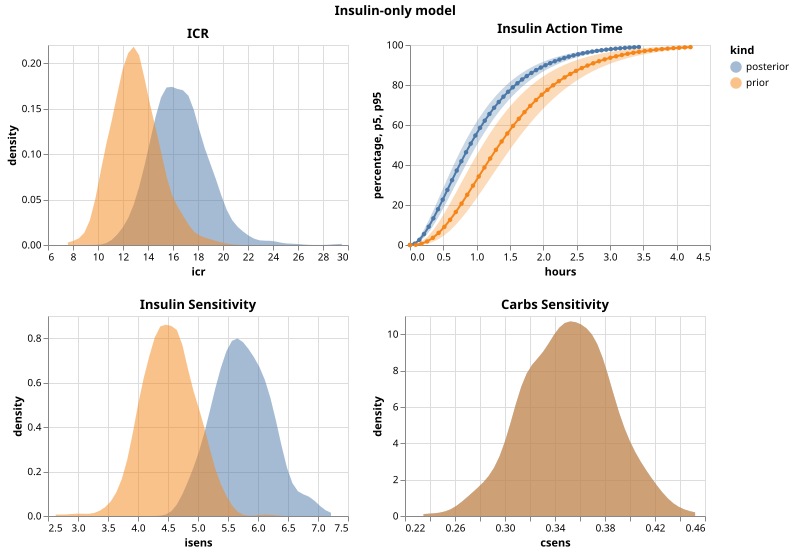

In [16]:
# plot ICR and CF
(
    charts.plot_fit_params(ifit, cfg, prior=ifit0, title="Insulin-only model")
    if ifit is not None
    else None
)

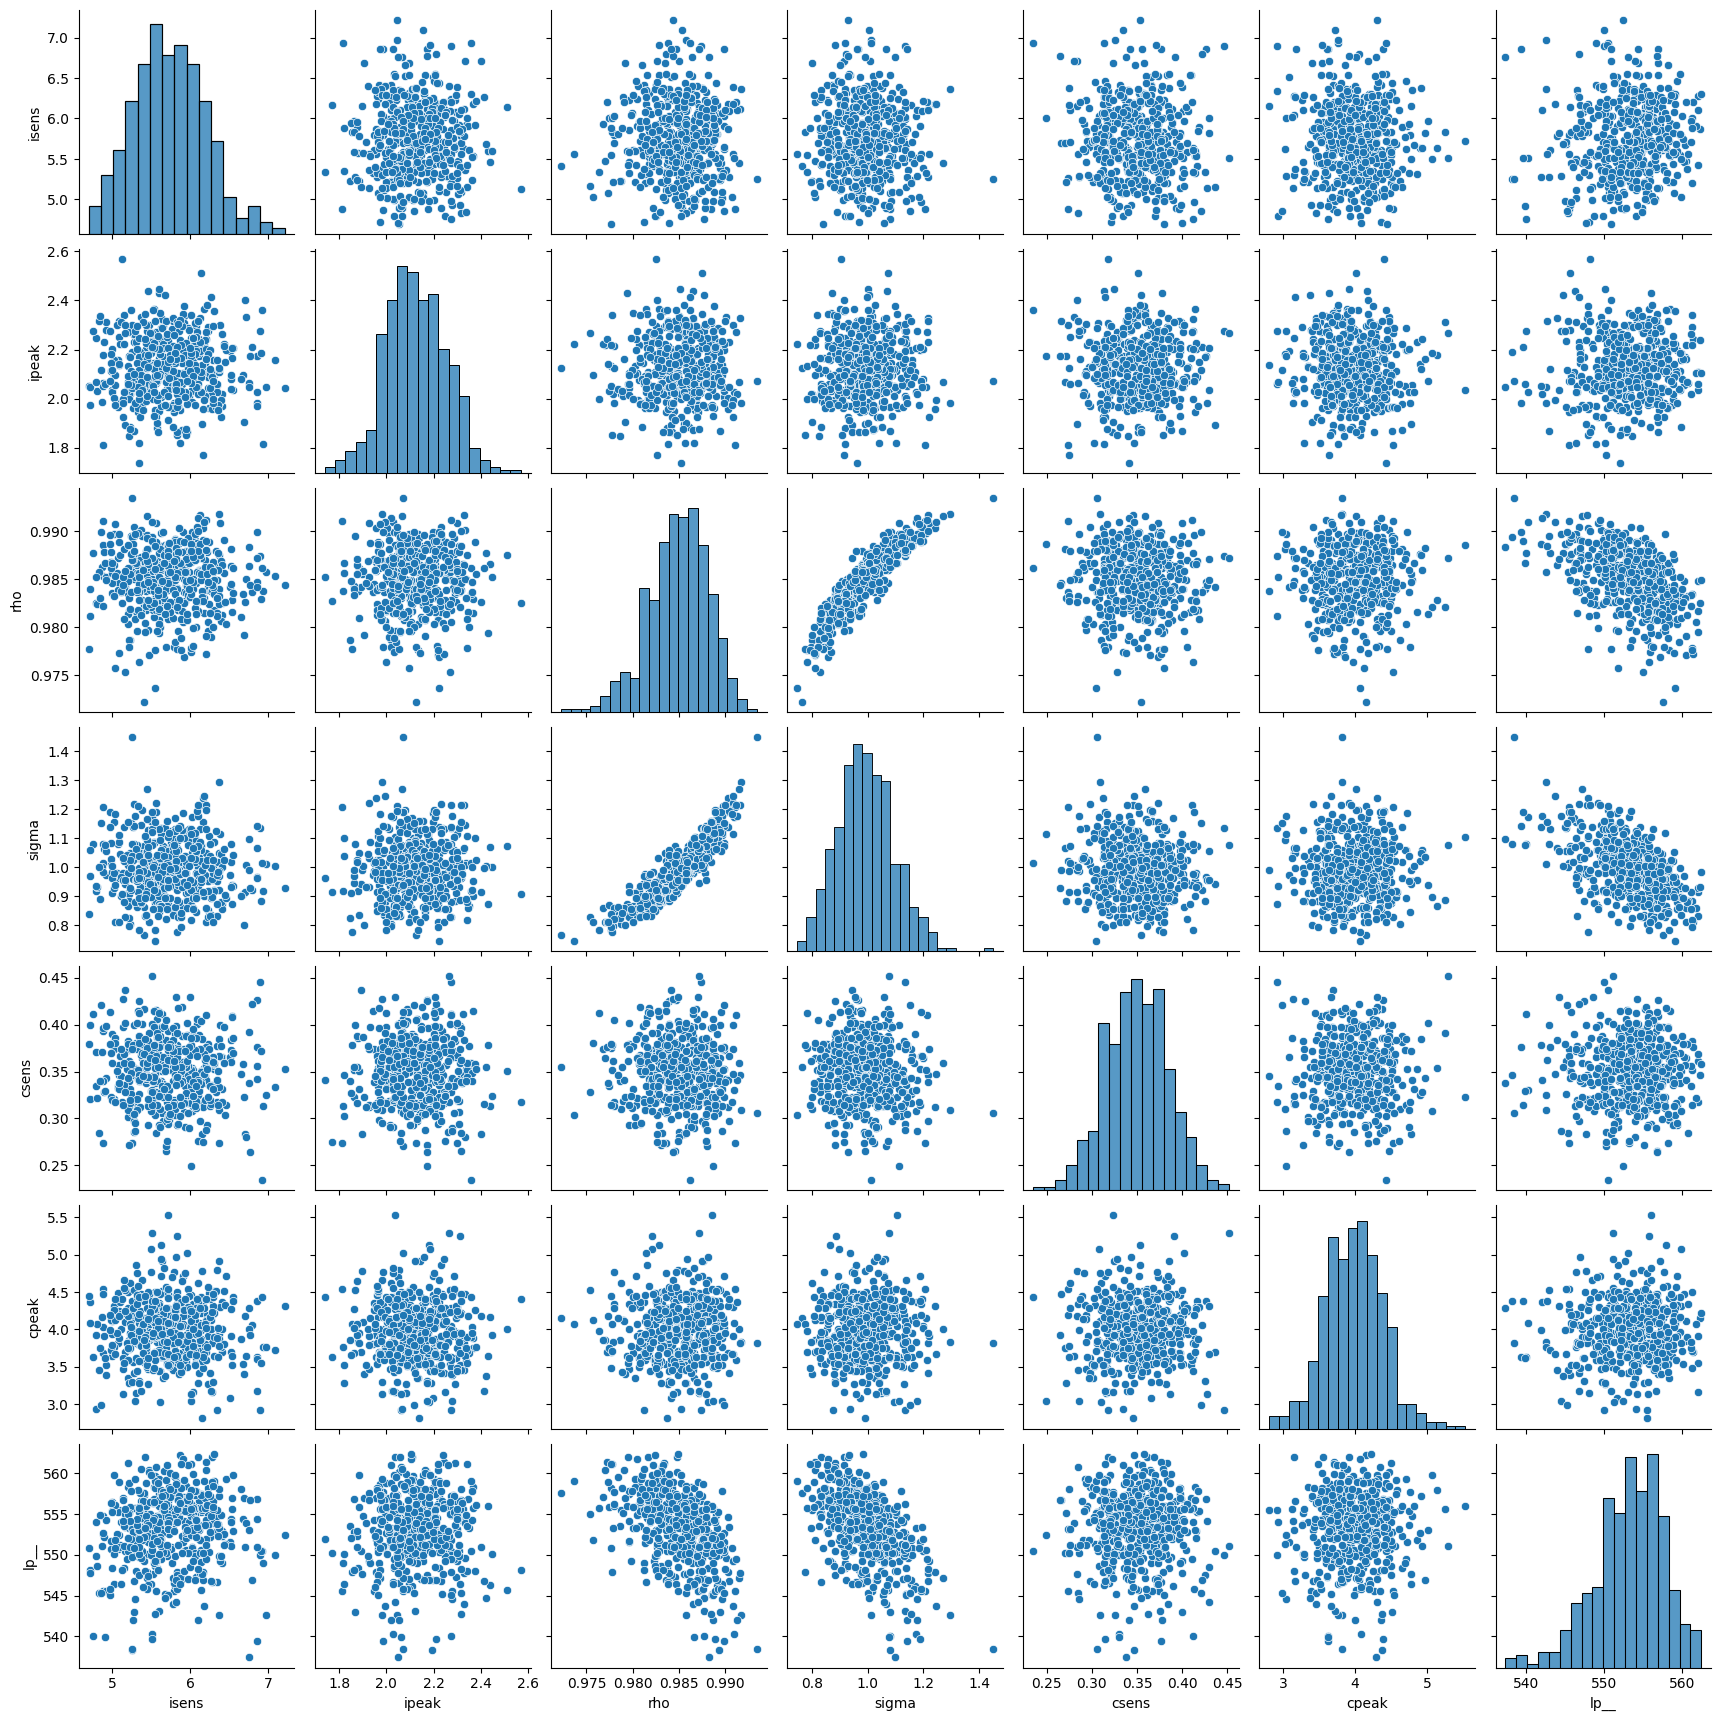

In [17]:
# csens and cpeak values are not estimated and taken from the prior.
# Visualize full posterior for insulin-only model
sns.pairplot(ifit.to_df()) if ifit is not None else None

In [19]:
# # Visualize predictions in each training chunk
# a, s = list(ifit.chunks.items())[2]
# ticka = a
# tickb = a + s
# charts.plot_predictions(ticka, tickb, data_df, ifit, cfg)

### Fit full model

Here we perform joint estimation of carbs and insulin params

In [20]:
def scale_std(arr, target_std):
    mean = arr.mean()
    std = arr.std()

    # Center, scale, then shift back
    scaled = (arr - mean) * (target_std / std) + mean
    return scaled

In [21]:
if ifit is not None:
    # use insulin-only fit as a prior for the full model
    fit0 = ifit.copy()
    fit0.isens = scale_std(fit0.isens, 0.1)  # set informative (narrow) prior
else:
    fit0 = dm.Fit.default(cfg)
fit0

Fit(isens=5.742 ipeak=2.124 rho=0.985 sigma=0.994 csens=0.35 cpeak=3.984 carbs=0 insulin=62 cpeaki=None ccorri=None chunks=20 bg0i=7.549 lp__=553.137 fit_at=None)

In [22]:
# Select time ranges to fit the full model
model = dm.DiaModel(cfg)

between_hours = [6, 12]  # morning
# between_hours = [12, 18]  # daytime
# between_hours = [18, 24]  # evening

chunks = model.select_chunks(data_df, between_hours=between_hours)
chunks.shape

(41,)

In [23]:
fit_full = model.fit(data_df, prior_fit=fit0, chunks=chunks)

In [24]:
fit_full

Fit(isens=5.803 ipeak=2.717 rho=0.981 sigma=1.275 csens=0.388 cpeak=2.708 carbs=267 insulin=446 cpeaki=2.736 ccorri=0.013 chunks=41 bg0i=6.557 lp__=559.612 fit_at=None)

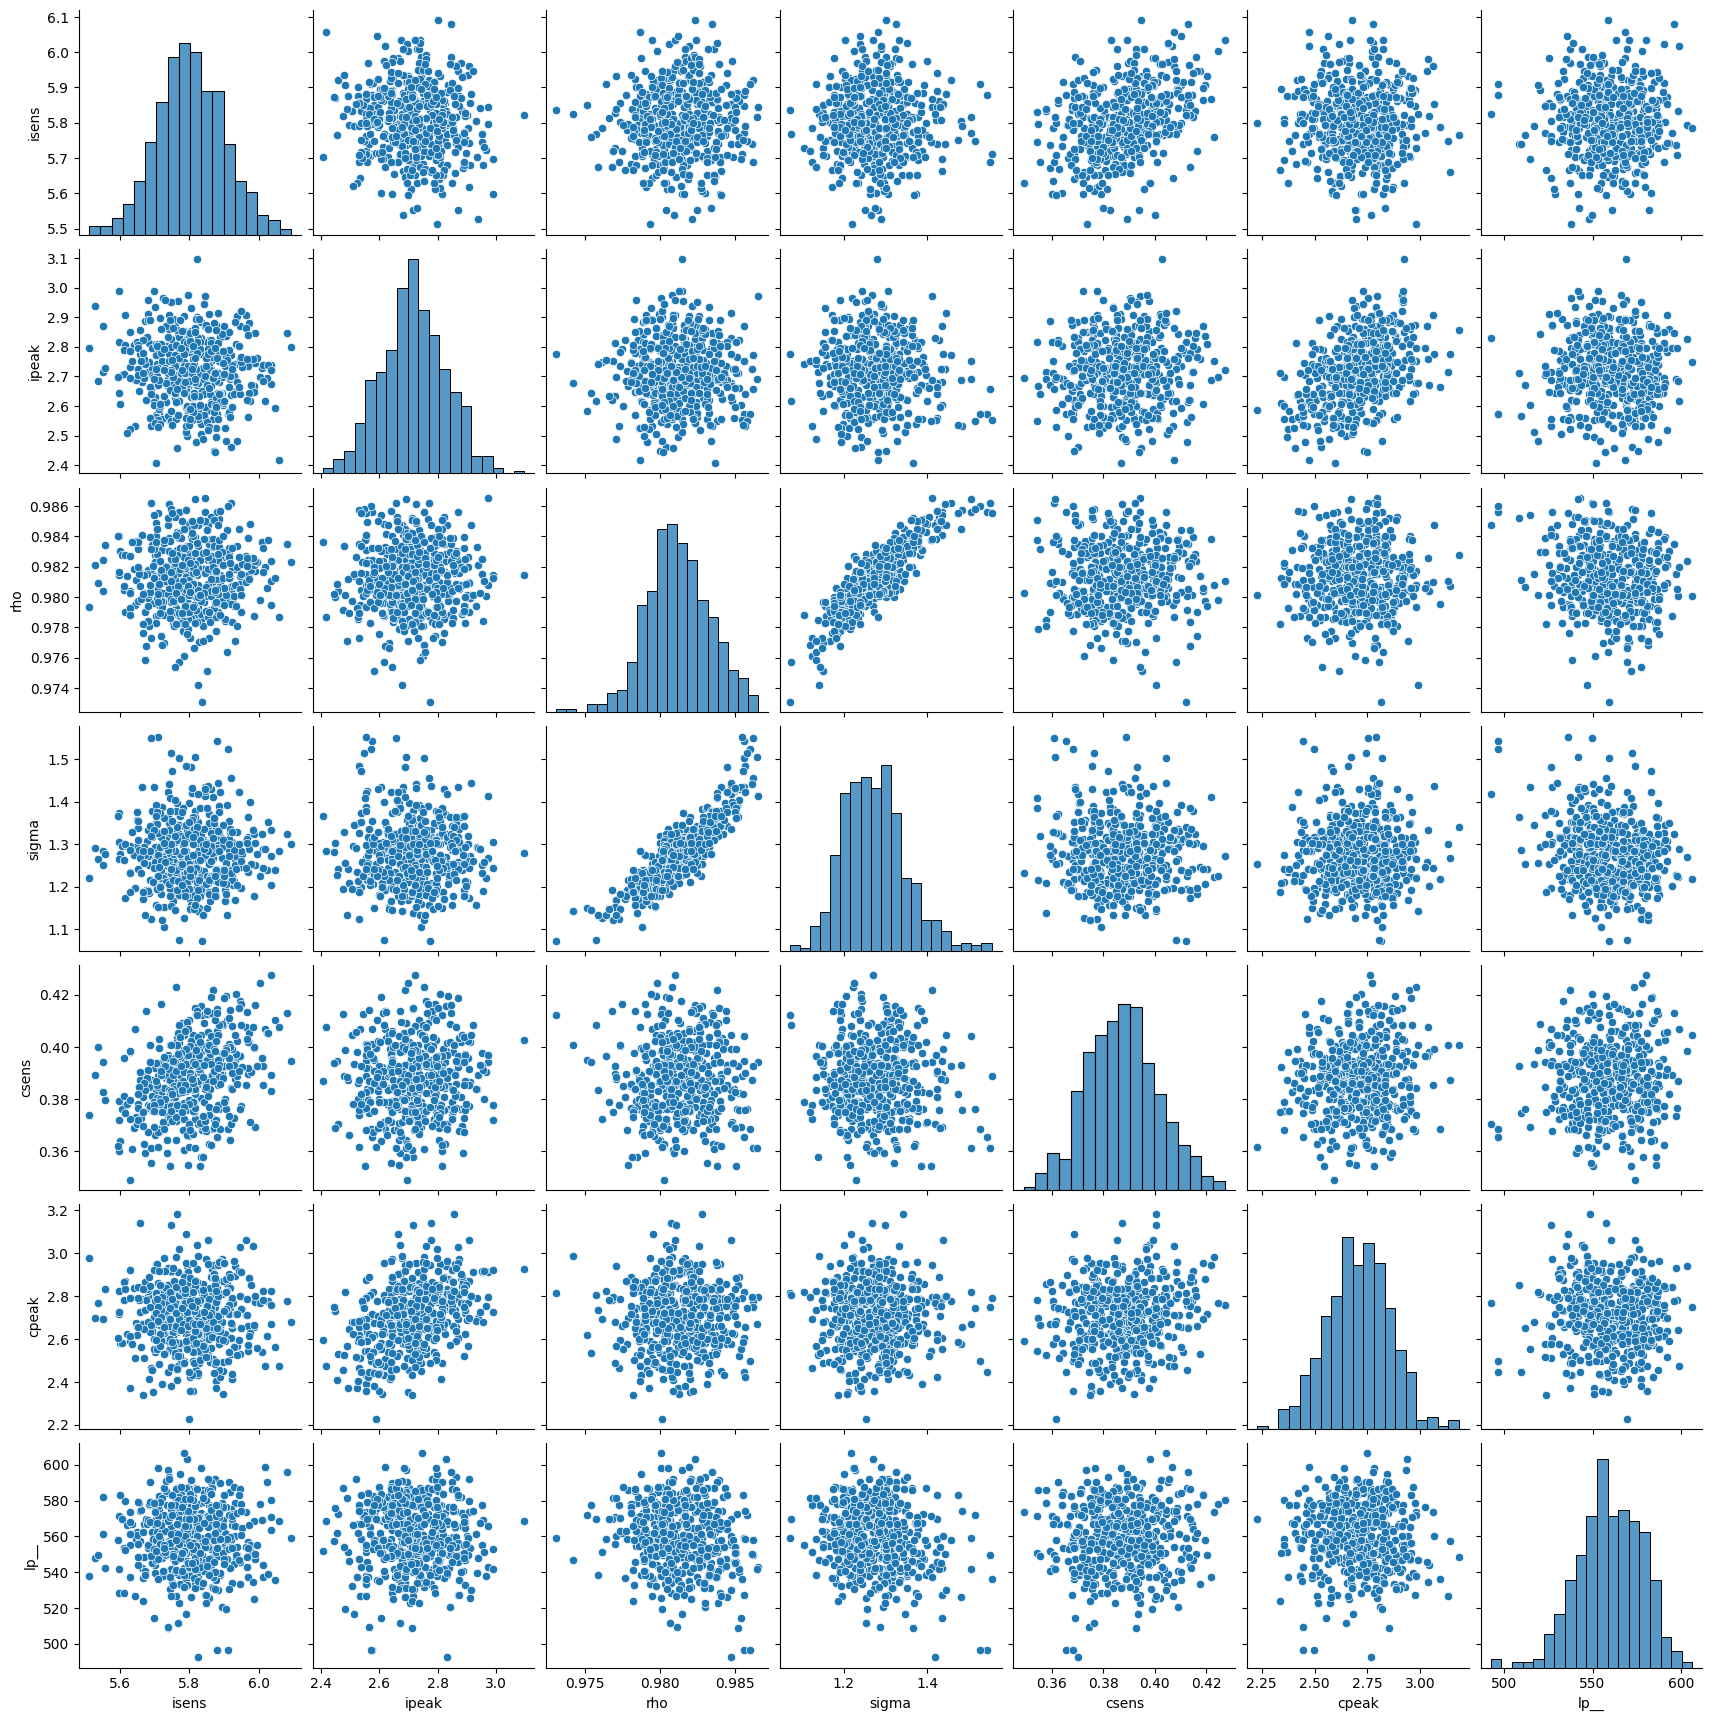

In [25]:
# Visualize full posterior for the full model
sns.pairplot(fit_full.to_df())

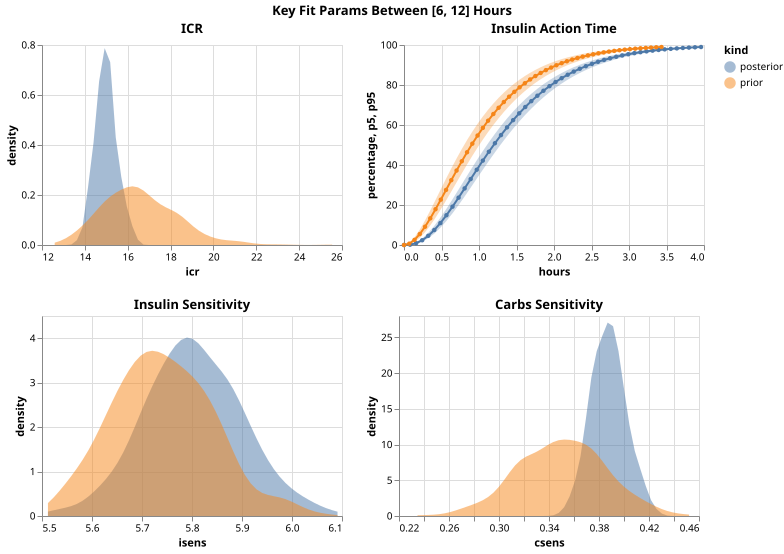

In [26]:
charts.plot_fit_params(
    fit_full, cfg, title=f"Key Fit Params Between {between_hours} Hours", prior=fit0
)

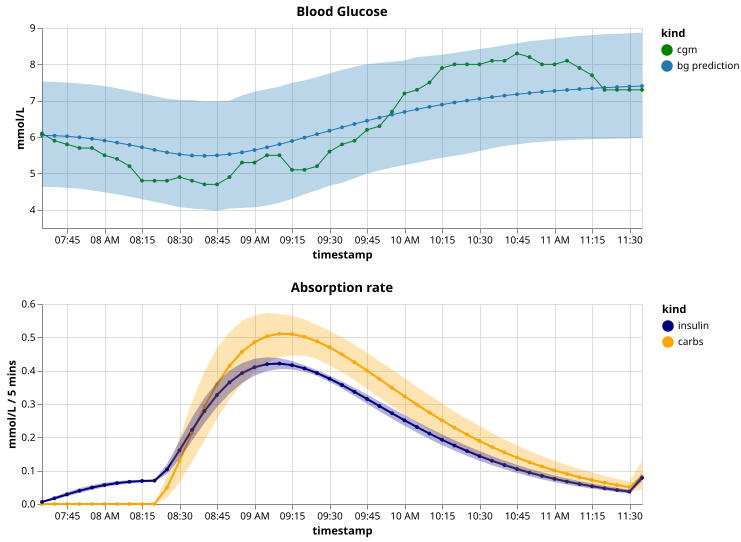

In [27]:
# visualize predictions in each training chunk
a, s = list(fit_full.chunks.items())[10]
ticka = a
tickb = a + s
charts.plot_predictions(ticka, tickb, data_df, fit_full, cfg)

### Fit full model incrementally

This allows tracking changes in parameters over time, which can help answer questions such as "when does the honeymoon period end?"

In [28]:
# DEBUG
fit0 = dm.Fit.default(cfg)
fit0

Fit(isens=4.499 ipeak=3.014 rho=0.902 sigma=0.998 csens=0.347 cpeak=3.999 carbs=0 insulin=0 cpeaki=None ccorri=None chunks=None bg0i=None lp__=None fit_at=None)

In [29]:
# perform incremental training to keep "local" params manageable
IntervalFit = namedtuple("IntervalFit", ["date", "data", "prior", "posterior"])

fits = []
model = dm.DiaModel(cfg)

# select last N intervals to speed up training
for date in intervals_df.index:
    data = data_df[data_df["date"] == date]
    chunks = model.select_chunks(data, between_hours=[6, 12])
    try:
        fit = model.fit(data, prior_fit=fit0, chunks=chunks)
    except Exception as e:
        print(f"Failed to fit date={date} err={e}")
        continue

    fits.append(IntervalFit(date, data, fit0, fit))
    fit0 = fit

len(fits)

27

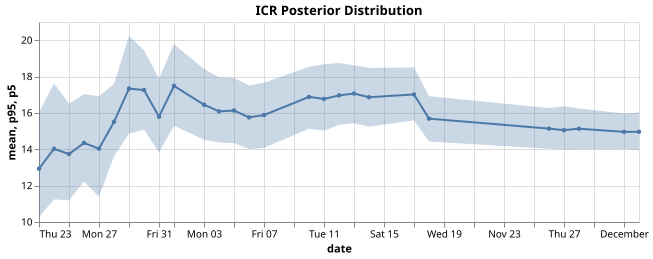

In [30]:
# visualize ICR posterior evolution over each interval
charts.plot_fits_density("icr", fits)

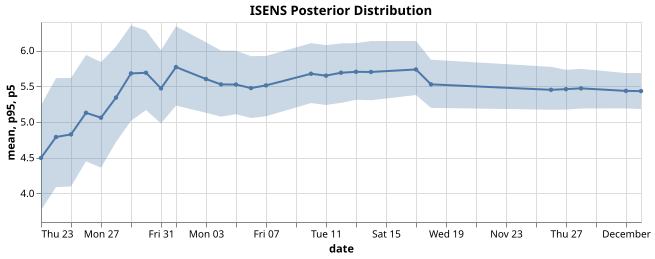

In [31]:
# visualize isens (CF) posterior evolution over each interval
charts.plot_fits_density("isens", fits)

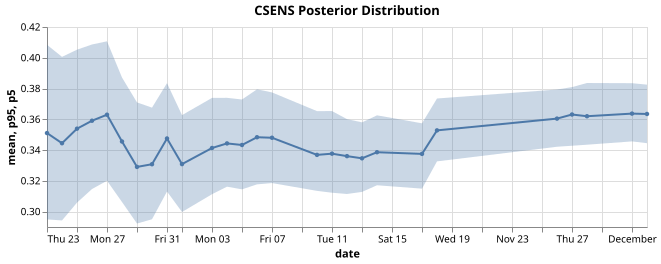

In [32]:
# visualize csens posterior evolution over each interval
charts.plot_fits_density("csens", fits)

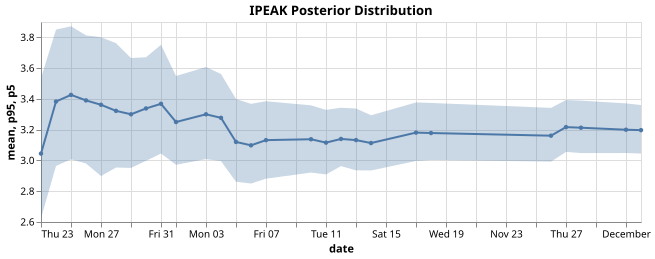

In [33]:
# visualize ipeak posterior evolution over each interval
charts.plot_fits_density("ipeak", fits)

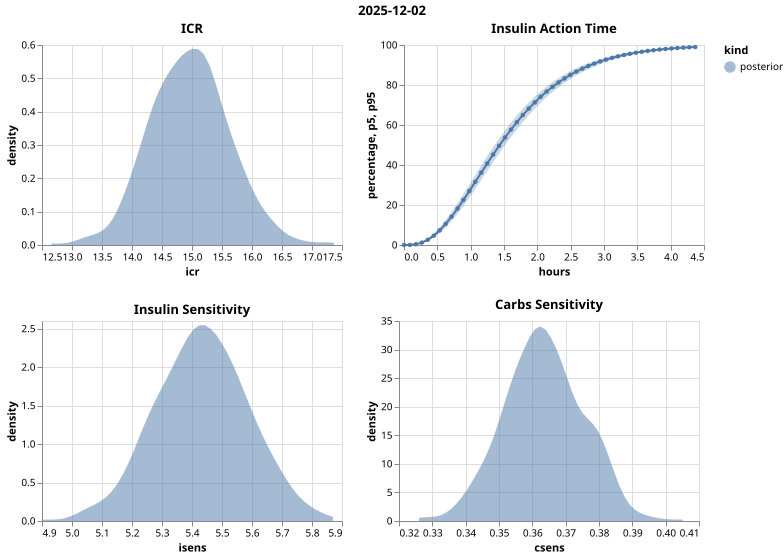

In [34]:
f = fits[-1]
charts.plot_fit_params(f.posterior, cfg, prior=None, title=f"{f.date}")

In [ ]:
# # visualize predictions in each training chunk
# a, s = list(f.posterior.chunks.items())[0]
# ticka = a
# tickb = a + s
# charts.plot_predictions(ticka, tickb, data_df, f.posterior, cfg)